
                       STEP 1: DATASET OVERVIEW                       
   Transaction_ID  Customer_ID  Product   Category  Quantity   Price  \
0               1         4444     Rice    Grocery         4   80.00   
1               1         3391     Milk      Dairy         4  469.89   
2               1         4385    Juice  Beverages         2   13.46   
3               1         3558  Chicken       Meat         2   32.87   
4               2         3214    Bread     Bakery         2  474.95   

  Store_Location Payment_Method  Discount        Date  
0        Kolkata           Card      0.02  2023-03-29  
1         Mumbai           Cash      0.19  2023-03-29  
2          Delhi           Cash      0.16  2023-03-29  
3        Chennai            UPI      0.14  2023-03-29  
4        Chennai           Card      0.24  2023-11-25  

               STEP 2: DATA CLEANING AND PREPROCESSING                

Total Records        : 69,789
Unique Transactions  : 20,000
Unique Products      : 10


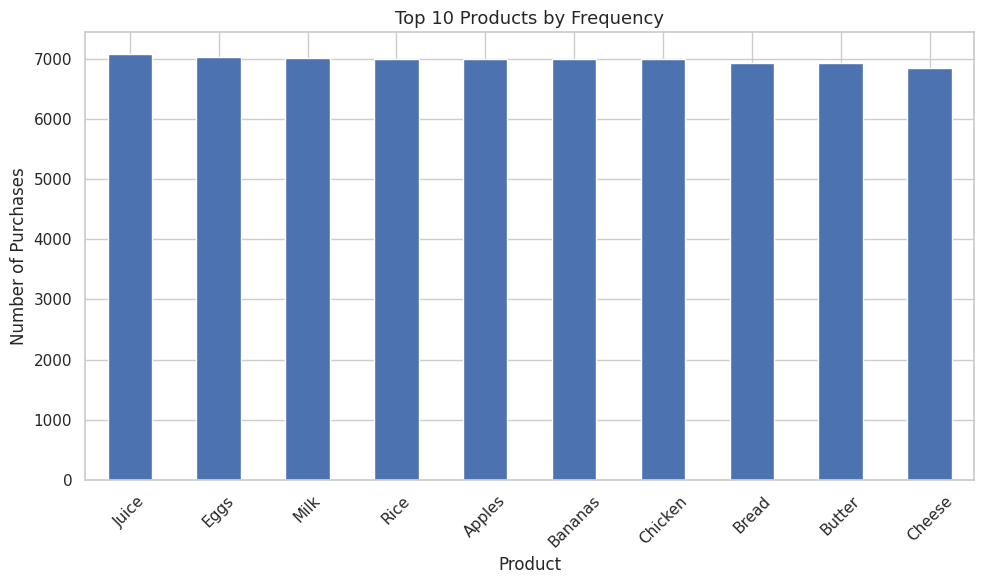


                   STEP 4: BASKET MATRIX DIMENSION                    
Shape: (20000, 10)

                 STEP 5: FREQUENT ITEMSETS (FIRST 5)                  
   support   itemsets
0  0.34965   (Apples)
1  0.34965  (Bananas)
2  0.34665    (Bread)
3  0.34665   (Butter)
4  0.34180   (Cheese)

              STEP 6: TOTAL ASSOCIATION RULES GENERATED               
98

               STEP 7.1: HIGH-PRIORITY ASSOCIATION RULE               

IF {'Rice'}  →  {'Apples'}

Support    : 0.114
Confidence : 0.326
Lift       : 0.932


               STEP 7.2: HIGH-PRIORITY ASSOCIATION RULE               

IF {'Apples'}  →  {'Rice'}

Support    : 0.114
Confidence : 0.326
Lift       : 0.932


               STEP 7.3: HIGH-PRIORITY ASSOCIATION RULE               

IF {'Apples'}  →  {'Butter'}

Support    : 0.113
Confidence : 0.322
Lift       : 0.929


               STEP 7.4: HIGH-PRIORITY ASSOCIATION RULE               

IF {'Butter'}  →  {'Apples'}

Support    : 0.113
Confidence : 0.325
Lift      

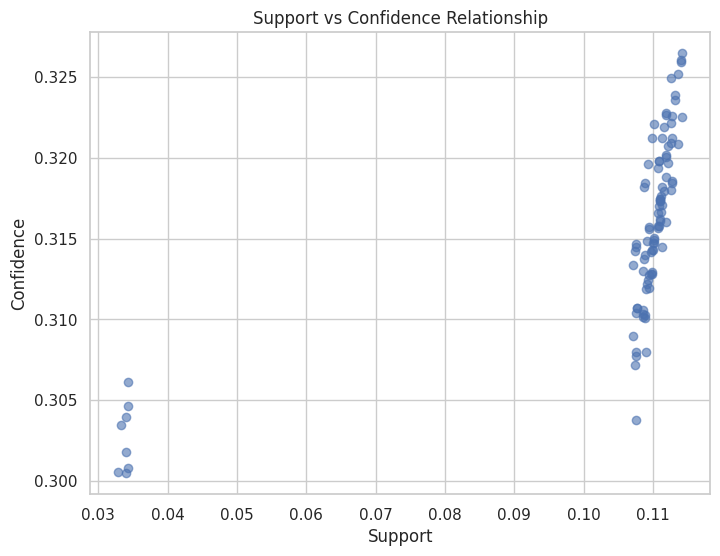

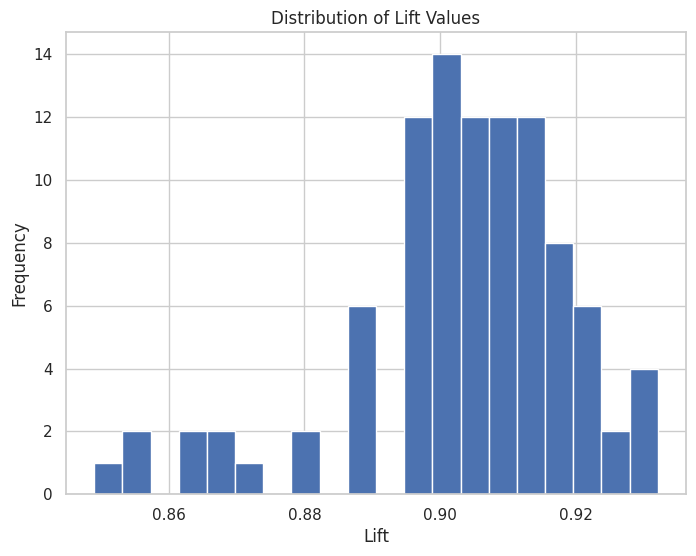

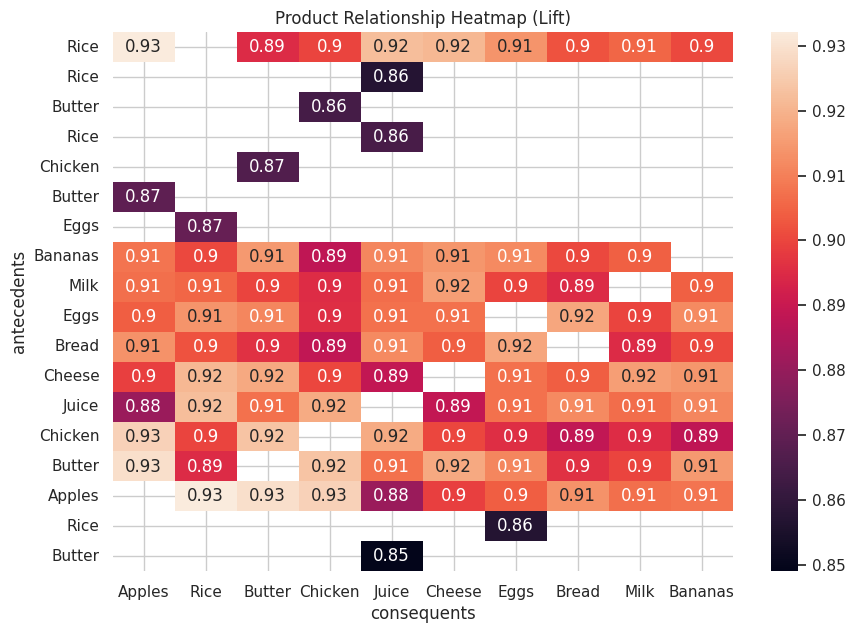

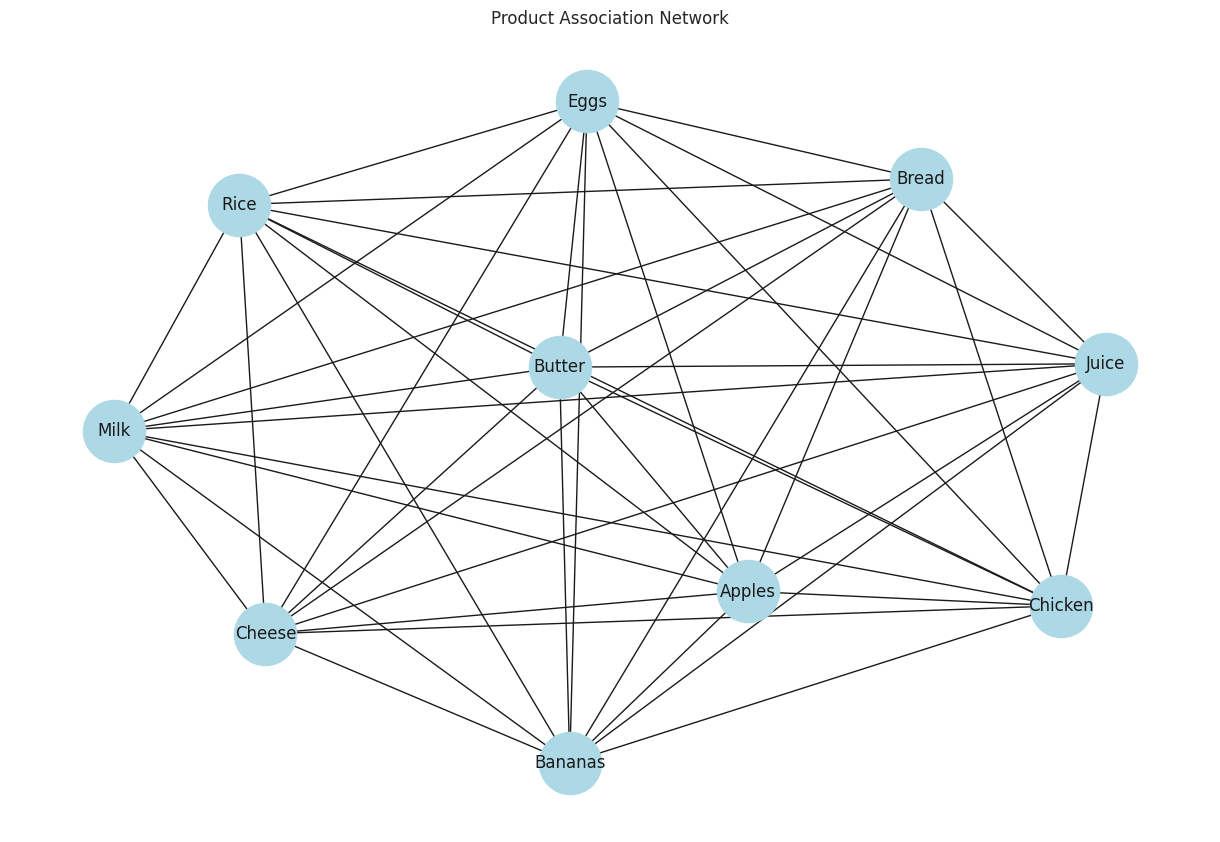


            STEP 11: BUSINESS INSIGHTS AND INTERPRETATION             

Number of Strong Associations: 0

Key Insights:


Analysis Completed Successfully.


In [1]:
# ==================================
# MARKET BASKET ANALYSIS SYSTEM
# ==================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# =========================
# BOX PRINT FUNCTION (IMPROVED)
# =========================
def print_box(step_no, title, content):
    border = "=" * 70
    print("\n" + border)
    print(f"STEP {step_no}: {title}".center(70))
    print(border)
    print(content)
    print(border)

# =========================
# STEP 1: LOAD DATASET
# =========================
df = pd.read_csv('market_basket_final.csv')
print_box(1, "DATASET OVERVIEW", df.head())

# =========================
# STEP 2: DATA CLEANING
# =========================
df = df.drop_duplicates()
df = df[df['Quantity'] > 0]

clean_info = f"""
Total Records        : {len(df):,}
Unique Transactions  : {df['Transaction_ID'].nunique():,}
Unique Products      : {df['Product'].nunique():,}

Missing Values:
{df.isnull().sum()}
"""
print_box(2, "DATA CLEANING AND PREPROCESSING", clean_info)

# =========================
# STEP 3: PURCHASE ANALYSIS
# =========================
top_products = df['Product'].value_counts().head(10)
print_box(3, "TOP 10 MOST FREQUENTLY PURCHASED PRODUCTS", top_products)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Frequency", fontsize=13)
plt.xlabel("Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# STEP 4: BASKET TRANSFORMATION
# =========================
basket = df.groupby(['Transaction_ID', 'Product'])['Quantity'] \
            .sum().unstack().fillna(0)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print_box(4, "BASKET MATRIX DIMENSION", f"Shape: {basket.shape}")

# =========================
# STEP 5: APRIORI ALGORITHM
# =========================
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)

print_box(5, "FREQUENT ITEMSETS (FIRST 5)", frequent_items.head())

# =========================
# STEP 6: ASSOCIATION RULES
# =========================
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)
rules = rules.sort_values(by='lift', ascending=False)

print_box(6, "TOTAL ASSOCIATION RULES GENERATED", len(rules))

# =========================
# STEP 7: TOP RULES
# =========================
for i, row in enumerate(rules.head(5).itertuples(), 1):
    rule_text = f"""
IF {set(row.antecedents)}  →  {set(row.consequents)}

Support    : {row.support:.3f}
Confidence : {row.confidence:.3f}
Lift       : {row.lift:.3f}
"""
    print_box(f"7.{i}", "HIGH-PRIORITY ASSOCIATION RULE", rule_text)

# =========================
# STEP 8: EVALUATION
# =========================
eval_text = f"""
Average Support    : {rules['support'].mean():.3f}
Average Confidence : {rules['confidence'].mean():.3f}
Average Lift       : {rules['lift'].mean():.3f}
"""
print_box(8, "RULE EVALUATION SUMMARY", eval_text)

# =========================
# STEP 9: VISUALIZATION
# =========================

# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.6)
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence Relationship")
plt.grid(True)
plt.show()
print(" ")
# Histogram
plt.figure(figsize=(8,6))
plt.hist(rules['lift'], bins=20)
plt.title("Distribution of Lift Values")
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.show()

# Heatmap
print(" ")

import seaborn as sns

# Create pivot table for lift
pivot = rules.pivot_table(
    index='antecedents',
    columns='consequents',
    values='lift'
)

# Convert frozenset to string
pivot.index = pivot.index.map(lambda x: list(x)[0])
pivot.columns = pivot.columns.map(lambda x: list(x)[0])

# Plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(pivot, annot=True)
plt.title("Product Relationship Heatmap (Lift)")
plt.show()

print(" ")

# =========================
# STEP 10: NETWORK GRAPH
# =========================
G = nx.Graph()

for _, row in rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G)

nx.draw(G, pos,
        with_labels=True,
        node_size=2000,
        node_color='lightblue')

plt.title("Product Association Network")
plt.show()

# =========================
# STEP 11: BUSINESS INSIGHTS
# =========================
strong_rules = rules[rules['lift'] > 1.5]

insight_text = f"""
Number of Strong Associations: {len(strong_rules)}

Key Insights:
"""

for _, row in strong_rules.head(3).iterrows():
    insight_text += f"\n- Customers buying {set(row['antecedents'])} also tend to buy {set(row['consequents'])}"

print_box(11, "BUSINESS INSIGHTS AND INTERPRETATION", insight_text)

print("\nAnalysis Completed Successfully.")